# Install and Import the Required Libraries

1.   List item
2.   List item



In [1]:
# Install all the required libraries
!pip install -U -q pdfplumber tiktoken openai chromadb sentence-transformers

zsh:1: command not found: pip


In [2]:
# Import all the required Libraries

import pdfplumber
from pathlib import Path
import pandas as pd
from operator import itemgetter
import json
import tiktoken
import openai
import chromadb

In [3]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

## 2. <font color = red> Read, Process, and Chunk the PDF Files

We will be using [pdfplumber](https://https://pypi.org/project/pdfplumber/) to read and process the PDF files.

`pdfplumber` allows for better parsing of the PDF file as it can read various elements of the PDF apart from the plain text, such as, tables, images, etc. It also offers wide functionaties and visual debugging features to help with advanced preprocessing as well.

In [4]:
# Define the path of the PDF
single_pdf_path = './PolicyDocuments/HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf'
# single_pdf_path = "/content/drive/My Drive/HelpMate/Policy Documents/HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf"

#### <font color = red>  2.1 Reading a single PDF file and exploring it through pdfplumber

In [5]:
# Open the PDF file
with pdfplumber.open(single_pdf_path) as pdf:

    # Get one of the pages from the PDF and examine it
    single_page = pdf.pages[5]

    # Extract text from the first page
    text = single_page.extract_text()

    # Extract tables from the first page
    tables = single_page.extract_tables()

    # Print the extracted text
    print(text)

iii. A rise in cardiac biomarkers or Troponin T or I in absence of overtischemic heart
disease OR following an intra-arterial cardiac procedure.
Kidney End stage renal disease presenting as chronic irreversible failure of both kidneys to
Failure function, as a result of which either regular renal dialysis (hemodialysis or peritoneal
3 requiring dialysis) is instituted or renal transplantation is carried out. Diagnosis has to be
regular confirmed by a specialist Medical Practitioner.
dialysis
Any cerebrovascular incident producing permanent neurological sequelae. This
includes infarction of brain tissue, thrombosis in an intracranial vessel, haemorrhage
and embolisation from an extracranial source. Diagnosis has to be confirmed by a
Stroke specialist Medical Practitioner and evidenced by typical clinical symptoms as well as
resulting typical findings in CT Scan or MRI of the brain. Evidence of permanent neurological
4 in deficit lasting for at least 3 months has to be produced.
permanen

In [1]:
# View the table in the page, if any

tables[0]

NameError: name 'tables' is not defined

#### <font color = red> 2.2 Extracting text from multiple PDFs

Let's now try and read multiple documents, extract text from them using appropriate preprocessing, and store them in a dataframe


In [7]:
# Define the path where all pdf documents are present

pdf_path = "./PolicyDocuments/"

In [8]:
# Function to check whether a word is present in a table or not for segregation of regular text and tables

def check_bboxes(word, table_bbox):
    # Check whether word is inside a table bbox.
    l = word['x0'], word['top'], word['x1'], word['bottom']
    r = table_bbox
    return l[0] > r[0] and l[1] > r[1] and l[2] < r[2] and l[3] < r[3]

In [9]:
# Function to extract text from a PDF file.
# 1. Declare a variable p to store the iteration of the loop that will help us store page numbers alongside the text
# 2. Declare an empty list 'full_text' to store all the text files
# 3. Use pdfplumber to open the pdf pages one by one
# 4. Find the tables and their locations in the page
# 5. Extract the text from the tables in the variable 'tables'
# 6. Extract the regular words by calling the function check_bboxes() and checking whether words are present in the table or not
# 7. Use the cluster_objects utility to cluster non-table and table words together so that they retain the same chronology as in the original PDF
# 8. Declare an empty list 'lines' to store the page text
# 9. If a text element in present in the cluster, append it to 'lines', else if a table element is present, append the table
# 10. Append the page number and all lines to full_text, and increment 'p'
# 11. When the function has iterated over all pages, return the 'full_text' list

def extract_text_from_pdf(pdf_path):
    p = 0
    full_text = []


    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_no = f"Page {p+1}"
            text = page.extract_text()

            tables = page.find_tables()
            table_bboxes = [i.bbox for i in tables]
            tables = [{'table': i.extract(), 'top': i.bbox[1]} for i in tables]
            non_table_words = [word for word in page.extract_words() if not any(
                [check_bboxes(word, table_bbox) for table_bbox in table_bboxes])]
            lines = []

            for cluster in pdfplumber.utils.cluster_objects(non_table_words + tables, itemgetter('top'), tolerance=5):

                if 'text' in cluster[0]:
                    try:
                        lines.append(' '.join([i['text'] for i in cluster]))
                    except KeyError:
                        pass

                elif 'table' in cluster[0]:
                    lines.append(json.dumps(cluster[0]['table']))


            full_text.append([page_no, " ".join(lines)])
            p +=1

    return full_text

*Now that we have defined the function for extracting the text and tables from a PDF, let's iterate and call this function for all the PDFs in our drive and store them in a list.*

In [10]:
# Define the directory containing the PDF files
pdf_directory = Path(pdf_path)

# Initialize an empty list to store the extracted texts and document names
data = []

# Loop through all files in the directory
for pdf_path in pdf_directory.glob("*.pdf"):

    # Process the PDF file
    print(f"...Processing {pdf_path.name}")

    # Call the function to extract the text from the PDF
    extracted_text = extract_text_from_pdf(pdf_path)

    # Convert the extracted list to a PDF, and add a column to store document names
    extracted_text_df = pd.DataFrame(extracted_text, columns=['Page No.', 'Page_Text'])
    extracted_text_df['Document Name'] = pdf_path.name

    # Append the extracted text and document name to the list
    data.append(extracted_text_df)

    # Print a message to indicate progress
    print(f"Finished processing {pdf_path.name}")

# Print a message to indicate all PDFs have been processed
print("All PDFs have been processed.")

...Processing HDFC-Life-Group-Term-Life-Policy.pdf
Finished processing HDFC-Life-Group-Term-Life-Policy.pdf
...Processing HDFC-Life-Smart-Pension-Plan-Policy-Document-Online.pdf
Finished processing HDFC-Life-Smart-Pension-Plan-Policy-Document-Online.pdf
...Processing HDFC-Life-Sanchay-Plus-Life-Long-Income-Option-101N134V19-Policy-Document.pdf
Finished processing HDFC-Life-Sanchay-Plus-Life-Long-Income-Option-101N134V19-Policy-Document.pdf
...Processing HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
Finished processing HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
...Processing HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
Finished processing HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
...Processing HDFC-Surgicare-Plan-101N043V01.pdf
Finished processing HDFC-Surgicare-Plan-101N043V01.pdf
...Processing HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf
Finished processing HDFC-Life-Sampoorna-Jeevan-101N158V04-Poli

In [11]:
# Concatenate all the DFs in the list 'data' together

insurance_pdfs_data = pd.concat(data, ignore_index=True)

In [12]:
insurance_pdfs_data

,Page No.,Page_Text,Document Name
0,Page 1,HDFC Life Group Term Life OF «OWNERNAME» Based...,HDFC-Life-Group-Term-Life-Policy.pdf
1,Page 2,PART A: Covering Letter with Policy Schedule <...,HDFC-Life-Group-Term-Life-Policy.pdf
2,Page 3,Address : Mobile/Landline Number : A1 Free Loo...,HDFC-Life-Group-Term-Life-Policy.pdf
3,Page 4,"[[""Name of Policy"", ""HDFC Life Group Term Life...",HDFC-Life-Group-Term-Life-Policy.pdf
4,Page 5,"[[""Policy No."", """"], [""Name & Address of Polic...",HDFC-Life-Group-Term-Life-Policy.pdf
...,...,...,...
212,Page 40,,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...
213,Page 41,,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...
214,Page 42,,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...
215,Page 43,,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...


In [13]:
# Check one of the extracted page texts to ensure that the text has been correctly read

insurance_pdfs_data.Page_Text[2]

'Address : Mobile/Landline Number : A1 Free Look Provisions: For the Master Policyholder The Master Policyholder shall have a period of 15 days from the date of receipt of the Master Policy document to review the terms and conditions of this Policy and if the Master Policyholder disagrees with any of the terms and conditions, he/she has the option to return the Master Policy stating the reasons for the cancellation upon which the Company shall refund the Premium paid subject to deduction of a proportionate risk Premium for the period of Insurance Cover in addition to the expenses incurred on medical examination (if any) and the stamp duty charges. All Benefits and rights under this Policy shall immediately stand terminated on the cancellation of the Policy. The Master Policyholder shall have a period of 30 days if the Policy is sourced through Direct Sales# from the date of receipt of the Master Policy document to review the terms and conditions of this Policy and if the Master Policyh

In [14]:
# Let's also check the length of all the texts as there might be some empty pages or pages with very few words that we can drop

insurance_pdfs_data['Text_Length'] = insurance_pdfs_data['Page_Text'].apply(lambda x: len(x.split(' ')))

In [15]:
insurance_pdfs_data['Text_Length']

0       57
1      400
2      618
3       67
4      174
      ... 
212      1
213      1
214      1
215      1
216      1
Name: Text_Length, Length: 217, dtype: int64

In [16]:
# Retain only the rows with a text length of at least 10

insurance_pdfs_data = insurance_pdfs_data.loc[insurance_pdfs_data['Text_Length'] >= 10]
insurance_pdfs_data

,Page No.,Page_Text,Document Name,Text_Length
0,Page 1,HDFC Life Group Term Life OF «OWNERNAME» Based...,HDFC-Life-Group-Term-Life-Policy.pdf,57
1,Page 2,PART A: Covering Letter with Policy Schedule <...,HDFC-Life-Group-Term-Life-Policy.pdf,400
2,Page 3,Address : Mobile/Landline Number : A1 Free Loo...,HDFC-Life-Group-Term-Life-Policy.pdf,618
3,Page 4,"[[""Name of Policy"", ""HDFC Life Group Term Life...",HDFC-Life-Group-Term-Life-Policy.pdf,67
4,Page 5,"[[""Policy No."", """"], [""Name & Address of Polic...",HDFC-Life-Group-Term-Life-Policy.pdf,174
...,...,...,...,...
206,Page 34,Paid-up Addition Factor per Re. 1 Cash Bonus u...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,18
207,Page 35,ANNEXURE – V Cash Value Factor per Re.1 vested...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,20
208,Page 36,Cash Value Factor per Re.1 vested Paid-up Addi...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,17
209,Page 37,Cash Value Factor per Re.1 vested Paid-up Addi...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,17


In [17]:
# Store the metadata for each page in a separate column

insurance_pdfs_data['Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)

In [18]:
insurance_pdfs_data

,Page No.,Page_Text,Document Name,Text_Length,Metadata
0,Page 1,HDFC Life Group Term Life OF «OWNERNAME» Based...,HDFC-Life-Group-Term-Life-Policy.pdf,57,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
1,Page 2,PART A: Covering Letter with Policy Schedule <...,HDFC-Life-Group-Term-Life-Policy.pdf,400,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
2,Page 3,Address : Mobile/Landline Number : A1 Free Loo...,HDFC-Life-Group-Term-Life-Policy.pdf,618,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
3,Page 4,"[[""Name of Policy"", ""HDFC Life Group Term Life...",HDFC-Life-Group-Term-Life-Policy.pdf,67,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
4,Page 5,"[[""Policy No."", """"], [""Name & Address of Polic...",HDFC-Life-Group-Term-Life-Policy.pdf,174,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
...,...,...,...,...,...
206,Page 34,Paid-up Addition Factor per Re. 1 Cash Bonus u...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,18,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...
207,Page 35,ANNEXURE – V Cash Value Factor per Re.1 vested...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,20,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...
208,Page 36,Cash Value Factor per Re.1 vested Paid-up Addi...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,17,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...
209,Page 37,Cash Value Factor per Re.1 vested Paid-up Addi...,HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-D...,17,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...


This concludes the chunking aspect also, as we can see that mostly the pages contain few hundred words, maximum going upto 1000. So, we don't need to chunk the documents further; we can perform the embeddings on individual pages. This strategy makes sense for 2 reasons:
1. The way insurance documents are generally structured, you will not have a lot of extraneous information in a page, and all the text pieces in that page will likely be interrelated.
2. We want to have larger chunk sizes to be able to pass appropriate context to the LLM during the generation layer.



```
# This is formatted as code
```

## 3. <font color = red> Generate and Store Embeddings using OpenAI and ChromaDB

In this section, we will embed the pages in the dataframe through OpenAI's `text-embedding-ada-002` model, and store them in a ChromaDB collection.

In [19]:
# Set the API key
filepath = "./6.ShopAssist_ Data + Demo/"

with open(filepath + "openai_key.txt", "r") as f:
  openai.api_key = ' '.join(f.readlines())

In [20]:
# Import the OpenAI Embedding Function into chroma

from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

In [21]:
# Define the path where chroma collections will be stored

chroma_data_path = './chroma/'

In [22]:
import chromadb

In [23]:
# Call PersistentClient()

client = chromadb.PersistentClient()

In [24]:
# Set up the embedding function using the OpenAI embedding model

model = "text-embedding-ada-002"
embedding_function = OpenAIEmbeddingFunction(api_key=openai.api_key, model_name=model)

In [25]:
# Initialise a collection in chroma and pass the embedding_function to it so that it used OpenAI embeddings to embed the documents

insurance_collection = client.get_or_create_collection(name='RAG_on_Insurance', embedding_function=embedding_function)

In [26]:
# Convert the page text and metadata from your dataframe to lists to be able to pass it to chroma

documents_list = insurance_pdfs_data["Page_Text"].tolist()
metadata_list = insurance_pdfs_data['Metadata'].tolist()

In [27]:
# Add the documents and metadata to the collection alongwith generic integer IDs. You can also feed the metadata information as IDs by combining the policy name and page no.

insurance_collection.add(
    documents= documents_list,
    ids = [str(i) for i in range(0, len(documents_list))],
    metadatas = metadata_list
)

In [28]:
# Let's take a look at the first few entries in the collection

insurance_collection.get(
    ids = ['0','1','2'],
    include = ['embeddings', 'documents', 'metadatas']
)

{'ids': ['0', '1', '2'],
 'embeddings': array([[-0.00745247, -0.01846271, -0.01808537, ..., -0.02005293,
          0.00757376, -0.00908985],
        [-0.01346942,  0.00593401,  0.00695524, ..., -0.01551189,
         -0.00992734, -0.02396675],
        [-0.00614571, -0.00087444,  0.00572421, ...,  0.00395664,
          0.00542848, -0.02711182]], shape=(3, 1536)),
 'documents': ['HDFC Life Group Term Life OF «OWNERNAME» Based on the Proposal and the declarations and any statement made or referred to therein, We will pay the Benefits mentioned in this Policy subject to the terms and conditions contained herein << Designation of the Authorised Signatory >> F&U dated 15th October 2022 UIN-101N169V02 P a ge | 0',
  'PART A: Covering Letter with Policy Schedule <dd-mm-yyyy> __________________ __________________ __________________ __________________ __________________ Your HDFC Life <Policy Name> with Policy No. <Policy no.> Dear Mr./Ms.___________________________, We thank you for choosing HDF

In [29]:
cache_collection = client.get_or_create_collection(name='Insurance_Cache', embedding_function=embedding_function)

In [30]:
cache_collection.peek()

{'ids': [],
 'embeddings': array([], dtype=float64),
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': []}

## 4. <font color = red> Semantic Search with Cache

In this section, we will perform a semantic search of a query in the collections embeddings to get several top semantically similar results.

In [43]:
# Read the user query

query = input()

 what is the benefits of accidental death ?


In [44]:
# Searh the Cache collection first
# Query the collection against the user query and return the top 20 results

cache_results = cache_collection.query(
    query_texts=query,
    n_results=1
)

In [45]:
cache_results

{'ids': [['what is the benefits of accidental death ?']],
 'embeddings': None,
 'documents': [['what is the benefits of accidental death ?']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'distances1': '0.3477376103401184',
    'ids2': '177',
    'documents9': 'HDFC Life Smart Pension Plan 101L164V02 – Terms and Conditions (Direct & Online Sales) (A Unit Linked Non-Participating Individual Pension Plan) PART C Product Core Benefits Subject to the provisions and fulfilment of the conditions of this Policy, the Company agrees to pay to the Eligible Person the Benefits under this Policy on the happening of the event/s subject to furnishing proof of happening of the event/s to the satisfaction of the Company. C.1 Death Benefit: Death Benefit is the amount payable on death of Life Assured to the Nominee after Risk Commencement Date and before the Policy Vesting Date and is subject to the terms of this Policy and the Policy remaining In

In [46]:
results = insurance_collection.query(
query_texts=query,
n_results=10
)
# results.items()

In [47]:
# Implementing Cache in Semantic Search

# Set a threshold for cache search
threshold = 0.2

ids = []
documents = []
distances = []
metadatas = []
results_df = pd.DataFrame()


# If the distance is greater than the threshold, then return the results from the main collection.

if cache_results['distances'][0] == [] or cache_results['distances'][0][0] > threshold:
      # Query the collection against the user query and return the top 10 results
      results = insurance_collection.query(
      query_texts=query,
      n_results=10
      )

      # Store the query in cache_collection as document w.r.t to ChromaDB so that it can be embedded and searched against later
      # Store retrieved text, ids, distances and metadatas in cache_collection as metadatas, so that they can be fetched easily if a query indeed matches to a query in cache
      Keys = []
      Values = []

      for key, val in results.items():
        if val is None or len(val) == 0:
          continue
        inner_list = val[0]

        for i in range(len(inner_list)):
          Keys.append(str(key)+str(i))
          Values.append(str(val[0][i]))


      cache_collection.add(
          documents= [query],
          ids = [query],  # Or if you want to assign integers as IDs 0,1,2,.., then you can use "len(cache_results['documents'])" as will return the no. of queries currently in the cache and assign the next digit to the new query."
          metadatas = dict(zip(Keys, Values))
      )

      print("Not found in cache. Found in main collection.")

      result_dict = {'Metadatas': results['metadatas'][0], 'Documents': results['documents'][0], 'Distances': results['distances'][0], "IDs":results["ids"][0]}
      results_df = pd.DataFrame.from_dict(result_dict)
      results_df


# If the distance is, however, less than the threshold, you can return the results from cache

elif cache_results['distances'][0][0] <= threshold:
      cache_result_dict = cache_results['metadatas'][0][0]

      # Loop through each inner list and then through the dictionary
      for key, value in cache_result_dict.items():
          if 'ids' in key:
              ids.append(value)
          elif 'documents' in key:
              documents.append(value)
          elif 'distances' in key:
              distances.append(value)
          elif 'metadatas' in key:
              metadatas.append(value)

      print("Found in cache!")

      # Create a DataFrame
      results_df = pd.DataFrame({
        'IDs': ids,
        'Documents': documents,
        'Distances': distances,
        'Metadatas': metadatas
      })


Found in cache!


In [48]:
results_df

,IDs,Documents,Distances,Metadatas
0,177,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3477376103401184,"{'Page_No.': 'Page 13', 'Policy_Name': 'HDFC-L..."
1,133,"[[""21. Progressive\nScleroderma"", ""22. Muscula...",0.3675435781478882,{'Policy_Name': 'HDFC-Life-Smart-Pension-Plan-...
2,10,"(i) Death Certificate, in original, issued by ...",0.35631412267684937,"{'Page_No.': 'Page 23', 'Policy_Name': 'HDFC-L..."
3,37,PART C Product Core Benefits BENEFITS PAYABLE ...,0.3763197064399719,"{'Page_No.': 'Page 4', 'Policy_Name': 'HDFC-Li..."
4,79,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3177793622016907,{'Policy_Name': 'HDFC-Life-Group-Poorna-Suraks...
5,52,PART C PRODUCT CORE BENEFITS BENEFITS PAYABLE ...,0.3609575927257538,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...
6,132,HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...,0.3685063123703003,"{'Page_No.': 'Page 7', 'Policy_Name': 'HDFC-Li..."
7,140,"Note: For the purpose of waiting period, Date ...",0.36220425367355347,"{'Page_No.': 'Page 8', 'Policy_Name': 'HDFC-Li..."
8,190,Part C 1. Benefits: (1) Benefits on Death or d...,0.36736568808555603,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...
9,129,Part B Definitions The following capitalized t...,0.36217445135116577,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...


## 5. <font color = red> Re-Ranking with a Cross Encoder

Re-ranking the results obtained from your semantic search can sometime significantly improve the relevance of the retrieved results. This is often done by passing the query paired with each of the retrieved responses into a cross-encoder to score the relevance of the response w.r.t. the query.

<br>

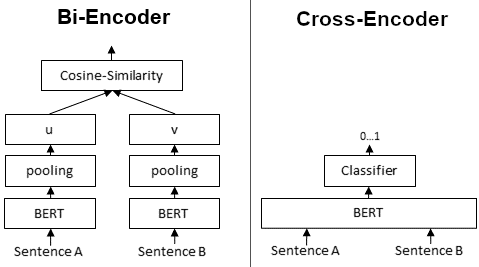

<br>

In [49]:
# Import the CrossEncoder library from sentence_transformers

from sentence_transformers import CrossEncoder, util

/Users/ujwalabhishek/myenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
# Initialise the cross encoder model

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

Loading weights: 100%|█████████████████████| 105/105 [00:00<00:00, 21281.62it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [51]:
# Test the cross encoder model

scores = cross_encoder.predict([['Does the insurance cover diabetic patients?', 'The insurance policy covers some pre-existing conditions including diabetes, heart diseases, etc. The policy does not howev'],
                                ['Does the insurance cover diabetic patients?', 'The premium rates for various age groups are given as follows. Age group (<18 years): Premium rate']])

In [52]:
scores

array([  3.8467658, -11.25288  ], dtype=float32)

In [53]:
# Input (query, response) pairs for each of the top 20 responses received from the semantic search to the cross encoder
# Generate the cross_encoder scores for these pairs

cross_inputs = [[query, response] for response in results_df['Documents']]
cross_rerank_scores = cross_encoder.predict(cross_inputs)

In [54]:
cross_rerank_scores

array([-5.8250303, -6.7558694, -5.4842753, -3.0247142, -4.9434633,
       -0.9568106, -6.436176 ,  3.777794 ,  1.9366246,  1.6350207],
      dtype=float32)

In [55]:
# Store the rerank_scores in results_df

results_df['Reranked_scores'] = cross_rerank_scores

In [56]:
results_df

,IDs,Documents,Distances,Metadatas,Reranked_scores
0,177,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3477376103401184,"{'Page_No.': 'Page 13', 'Policy_Name': 'HDFC-L...",-5.825030
1,133,"[[""21. Progressive\nScleroderma"", ""22. Muscula...",0.3675435781478882,{'Policy_Name': 'HDFC-Life-Smart-Pension-Plan-...,-6.755869
2,10,"(i) Death Certificate, in original, issued by ...",0.35631412267684937,"{'Page_No.': 'Page 23', 'Policy_Name': 'HDFC-L...",-5.484275
3,37,PART C Product Core Benefits BENEFITS PAYABLE ...,0.3763197064399719,"{'Page_No.': 'Page 4', 'Policy_Name': 'HDFC-Li...",-3.024714
4,79,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3177793622016907,{'Policy_Name': 'HDFC-Life-Group-Poorna-Suraks...,-4.943463
5,52,PART C PRODUCT CORE BENEFITS BENEFITS PAYABLE ...,0.3609575927257538,{'Policy_Name': 'HDFC-Life-Group-Term-Life-Pol...,-0.956811
6,132,HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...,0.3685063123703003,"{'Page_No.': 'Page 7', 'Policy_Name': 'HDFC-Li...",-6.436176
7,140,"Note: For the purpose of waiting period, Date ...",0.36220425367355347,"{'Page_No.': 'Page 8', 'Policy_Name': 'HDFC-Li...",3.777794
8,190,Part C 1. Benefits: (1) Benefits on Death or d...,0.36736568808555603,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...,1.936625
9,129,Part B Definitions The following capitalized t...,0.36217445135116577,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...,1.635021


In [57]:
# Return the top 3 results from semantic search

top_3_semantic = results_df.sort_values(by='Distances')
top_3_semantic[:3]

,IDs,Documents,Distances,Metadatas,Reranked_scores
4,79,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3177793622016907,{'Policy_Name': 'HDFC-Life-Group-Poorna-Suraks...,-4.943463
0,177,HDFC Life Smart Pension Plan 101L164V02 – Term...,0.3477376103401184,"{'Page_No.': 'Page 13', 'Policy_Name': 'HDFC-L...",-5.825030
2,10,"(i) Death Certificate, in original, issued by ...",0.35631412267684937,"{'Page_No.': 'Page 23', 'Policy_Name': 'HDFC-L...",-5.484275


In [58]:
# Return the top 3 results after reranking

top_3_rerank = results_df.sort_values(by='Reranked_scores', ascending=False)
top_3_rerank[:3]

,IDs,Documents,Distances,Metadatas,Reranked_scores
7,140,"Note: For the purpose of waiting period, Date ...",0.36220425367355347,"{'Page_No.': 'Page 8', 'Policy_Name': 'HDFC-Li...",3.777794
8,190,Part C 1. Benefits: (1) Benefits on Death or d...,0.36736568808555603,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...,1.936625
9,129,Part B Definitions The following capitalized t...,0.36217445135116577,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...,1.635021


In [59]:
top_3_RAG = top_3_rerank[["Documents", "Metadatas"]][:3]

In [60]:
top_3_RAG

,Documents,Metadatas
7,"Note: For the purpose of waiting period, Date ...","{'Page_No.': 'Page 8', 'Policy_Name': 'HDFC-Li..."
8,Part C 1. Benefits: (1) Benefits on Death or d...,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...
9,Part B Definitions The following capitalized t...,{'Policy_Name': 'HDFC-Life-Sampoorna-Jeevan-10...


## 6. Retrieval Augmented Generation

Now that we have the final top search results, we can pass it to an GPT 3.5 along with the user query and a well-engineered prompt, to generate a direct answer to the query along with citations, rather than returning whole pages/chunks.

In [61]:
# Define the function to generate the response. Provide a comprehensive prompt that passes the user query and the top 3 results to the model

def generate_response(query, results_df):
    """
    Generate a response using GPT-3.5's ChatCompletion based on the user query and retrieved information.
    """
    messages = [
                {"role": "system", "content":  "You are a helpful assistant in the insurance domain who can effectively answer user queries about insurance policies and documents."},
                {"role": "user", "content": f"""You are a helpful assistant in the insurance domain who can effectively answer user queries about insurance policies and documents.
                                                You have a question asked by the user in '{query}' and you have some search results from a corpus of insurance documents in the dataframe '{top_3_RAG}'. These search results are essentially one page of an insurance document that may be relevant to the user query.

                                                The column 'documents' inside this dataframe contains the actual text from the policy document and the column 'metadata' contains the policy name and source page. The text inside the document may also contain tables in the format of a list of lists where each of the nested lists indicates a row.

                                                Use the documents in '{top_3_RAG}' to answer the query '{query}'. Frame an informative answer and also, use the dataframe to return the relevant policy names and page numbers as citations.

                                                Follow the guidelines below when performing the task.
                                                1. Try to provide relevant/accurate numbers if available.
                                                2. You don’t have to necessarily use all the information in the dataframe. Only choose information that is relevant.
                                                3. If the document text has tables with relevant information, please reformat the table and return the final information in a tabular in format.
                                                3. Use the Metadatas columns in the dataframe to retrieve and cite the policy name(s) and page numbers(s) as citation.
                                                4. If you can't provide the complete answer, please also provide any information that will help the user to search specific sections in the relevant cited documents.
                                                5. You are a customer facing assistant, so do not provide any information on internal workings, just answer the query directly.

                                                The generated response should answer the query directly addressing the user and avoiding additional information. If you think that the query is not relevant to the document, reply that the query is irrelevant. Provide the final response as a well-formatted and easily readable text along with the citation. Provide your complete response first with all information, and then provide the citations.
                                                """},
              ]

    response = openai.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages
    )

    return response.choices[0].message.content.split('\n')

In [62]:
# Generate the response

response = generate_response(query, top_3_RAG)

In [63]:
# Print the response

print("\n".join(response))

The benefits of accidental death coverage in the HDFC-Life-Sampoorna-Jeevan-10 insurance policy include the following:

1. Accidental Death Benefit: The policy provides a specific amount as a benefit in case the insured person dies due to an accident.

Please refer to the HDFC-Life-Sampoorna-Jeevan-10 insurance policy document on Page 8 for more detailed information on the benefits of accidental death coverage.

Citation:
- Policy Name: HDFC-Life-Sampoorna-Jeevan-10
- Page No.: Page 8
